In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


6.857142857142858
Index where x position exceeds target: 40


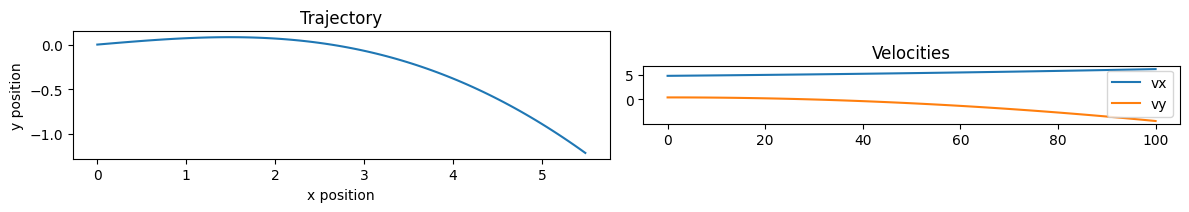

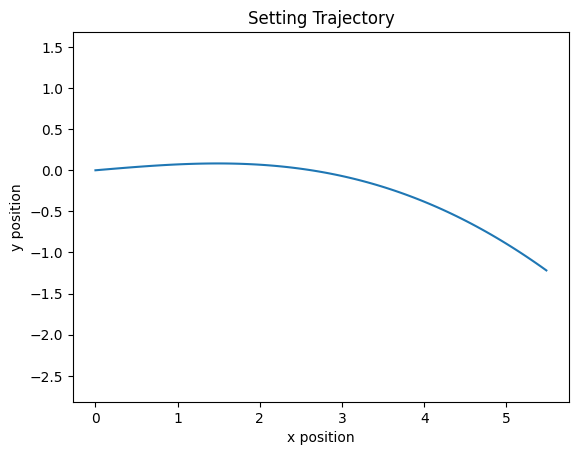

In [11]:


def volleyball(v):
    """
    Calculate the derivatives for the volleyball system
    """
    Cd = 0.48
    rho = 1.225
    A = 0.0346
    m = 0.27
    
    C = Cd * rho * A / (2 * m)
    
    x1, x2, y1, y2 = v
    
    dvdt = np.zeros(4)
    dvdt[0] = x2
    dvdt[1] = C * x1**2
    dvdt[2] = y2
    dvdt[3] = C * y1**2 - 9.81
    
    return dvdt

def plotting(tmax, dt, v0, theta):
    """
    Simulate and plot the volleyball trajectory
    """
    Cd = 0.48
    rho = 1.225
    A = 0.0346
    m = 0.27
    
    C = Cd * rho * A / (2 * m)
    
    # Convert theta to radians for numpy
    theta_rad = np.deg2rad(theta)
    nhat = np.array([np.cos(theta_rad), np.sin(theta_rad)])
    v0 = nhat * v0
    
    t = 0
    nhat = v0 / np.linalg.norm(v0)
    Di = C * v0**2 * nhat
    
    v = np.array([v0[0], Di[0], v0[1], Di[1]])
    
    vel_arr = v0.reshape(2, 1)
    pos_arr = np.zeros((2, 1))
    new_pos = pos_arr[:, -1] + v0 * dt
    pos_arr = np.hstack([pos_arr, new_pos.reshape(2, 1)])
    
    while t < tmax:
        dvdt = volleyball(v)
        v = v + dvdt * dt
        new_vel = np.array([v[0], v[2]]).reshape(2, 1)
        vel_arr = np.hstack([vel_arr, new_vel])
        
        int_pos = pos_arr[:, -1]
        new_pos = int_pos + new_vel.reshape(2) * dt
        pos_arr = np.hstack([pos_arr, new_pos.reshape(2, 1)])
        
        t = t + dt
    
    # Create two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot trajectory
    ax1.plot(pos_arr[0, :], pos_arr[1, :])
    ax1.set_aspect('equal')
    ax1.set_title('Trajectory')
    ax1.set_xlabel('x position')
    ax1.set_ylabel('y position')
    
    # Plot velocities
    ax2.plot(vel_arr.T)
    ax2.set_aspect('equal')
    ax2.set_title('Velocities')
    ax2.legend(['vx', 'vy'])
    
    plt.tight_layout()
    return pos_arr

def setting(xf, yf, v0, theta):
    """
    Find and plot the trajectory that reaches the target point
    """
    theta_rad = np.deg2rad(theta)
    nhat = np.array([np.cos(theta_rad), np.sin(theta_rad)])
    v_guess = nhat * v0
    
    pos_arr = plotting(1, 0.01, v_guess[0], v_guess[1])
    
    i = 0
    while i < pos_arr.shape[1] and pos_arr[0, i] < xf:
        i += 1
    
    plt.figure()
    plt.plot(pos_arr[0, :], pos_arr[1, :])
    plt.axis('equal')
    plt.title('Setting Trajectory')
    plt.xlabel('x position')
    plt.ylabel('y position')
    
    print(f"Index where x position exceeds target: {i}")
    return pos_arr

# Example usage
if __name__ == "__main__":
    # Test the functions
    # pos_arr = plotting(1, 0.01, 5, 45)  # 1 second simulation, dt=0.01, v0=10 m/s, theta=45 degrees
    # plt.show()
    
    v0 = 0.8/(7*1/60)
    print(v0)

    # Test setting function
    result = setting(2, 2, v0, 45)  # target x=2, y=1, initial velocity=10 m/s, angle=45 degrees
    plt.show()